LAB 5: Utilize tools to create effective data visualizations (e.g., line charts, bar charts,
heat maps, box plots) to derive key insights from the dataset

In [ ]:
# Matplotlib forms basis for visualization in Python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# We will use the Seaborn library
import seaborn as sns
sns.set()
# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
data_url = DATA_URL + "telecom_churn.csv"
df = pd.read_csv(data_url)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


array([[<Axes: title={'center': 'Total day minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>]], dtype=object)

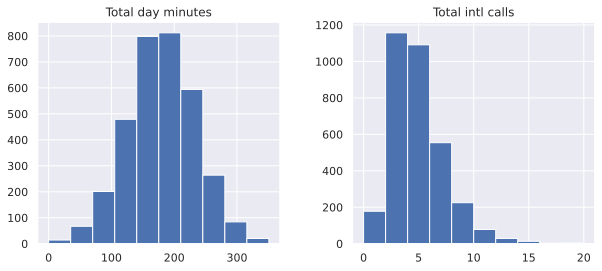

In [ ]:
# Specify the features to be visualized
selected_features = ["Total day minutes", "Total intl calls"]
# Plot histograms for the selected features with specified figure size
df[selected_features].hist(figsize=(10, 4))


array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

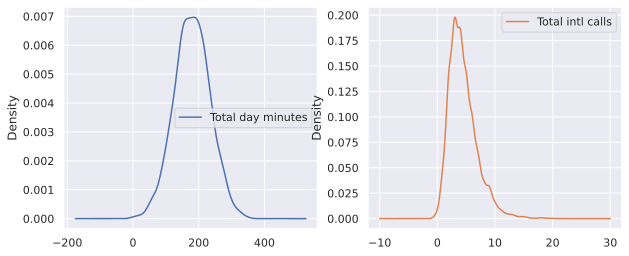

In [ ]:
df[selected_features].plot(
kind="density",
subplots=True,
layout=(1, 2),
sharex=False,
figsize=(10, 4)
)


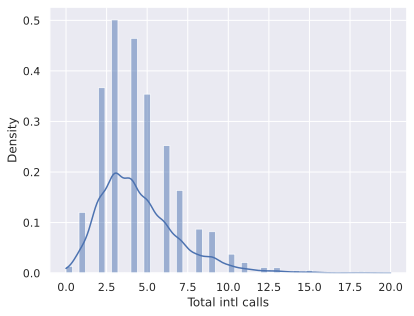

In [ ]:
sns.histplot(df["Total intl calls"], kde=True, stat="density");


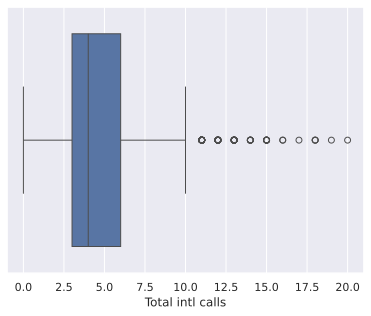

In [ ]:
sns.boxplot(x="Total intl calls", data=df);

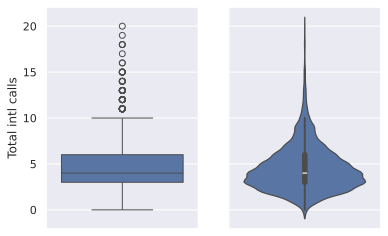

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(6, 4))
sns.boxplot(data=df["Total intl calls"], ax=axes[0])
sns.violinplot(data=df["Total intl calls"], ax=axes[1]);

In [ ]:
df[selected_features].describe()

,Total day minutes,Total intl calls
count,3333.000000,3333.000000
mean,179.775098,4.479448
std,54.467389,2.461214
min,0.000000,0.000000
25%,143.700000,3.000000
50%,179.400000,4.000000
75%,216.400000,6.000000
max,350.800000,20.000000


In [ ]:
df["Churn"].value_counts()


,count
Churn,
False,2850
True,483


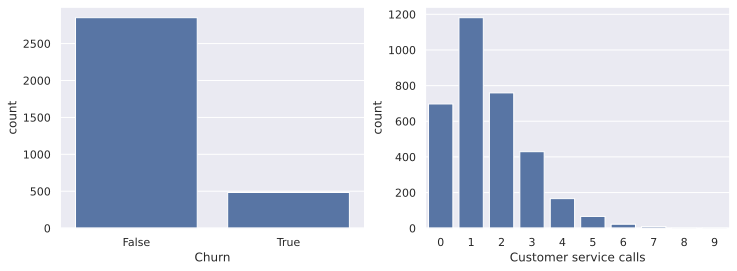

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.countplot(x="Churn", data=df, ax=axes[0])
sns.countplot(x="Customer service calls", data=df, ax=axes[1]);

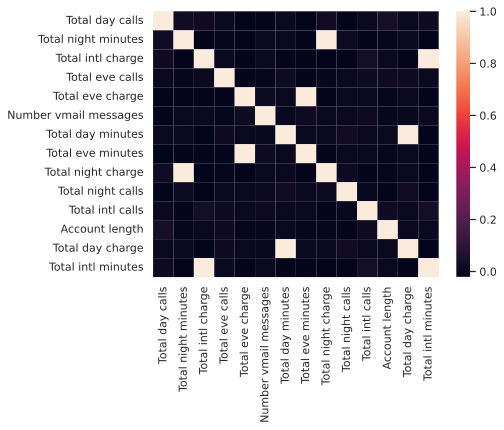

In [ ]:
# Drop non-numerical variables
numerical = list(
set(df.columns)
- set(
[
"State",
"International plan",
"Voice mail plan",
"Area code",
"Churn",
"Customer service calls",
]
)
)
# Calculate and plot
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix);


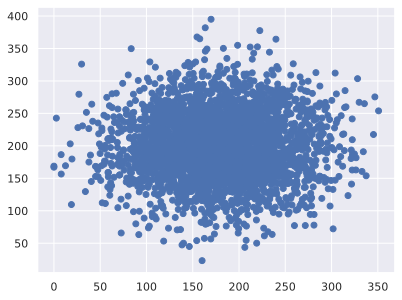

In [ ]:
plt.scatter(df["Total day minutes"], df["Total night minutes"]);


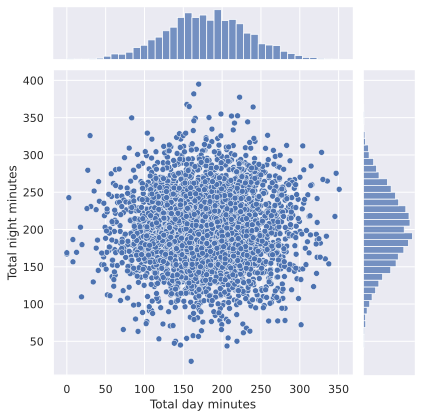

In [ ]:
sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="scatter");


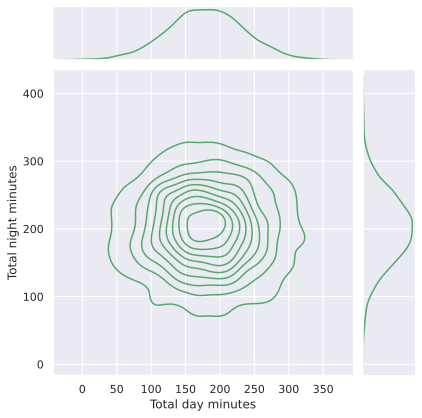

In [ ]:
sns.jointplot(
x="Total day minutes", y="Total night minutes", data=df, kind="kde", color="g"
);

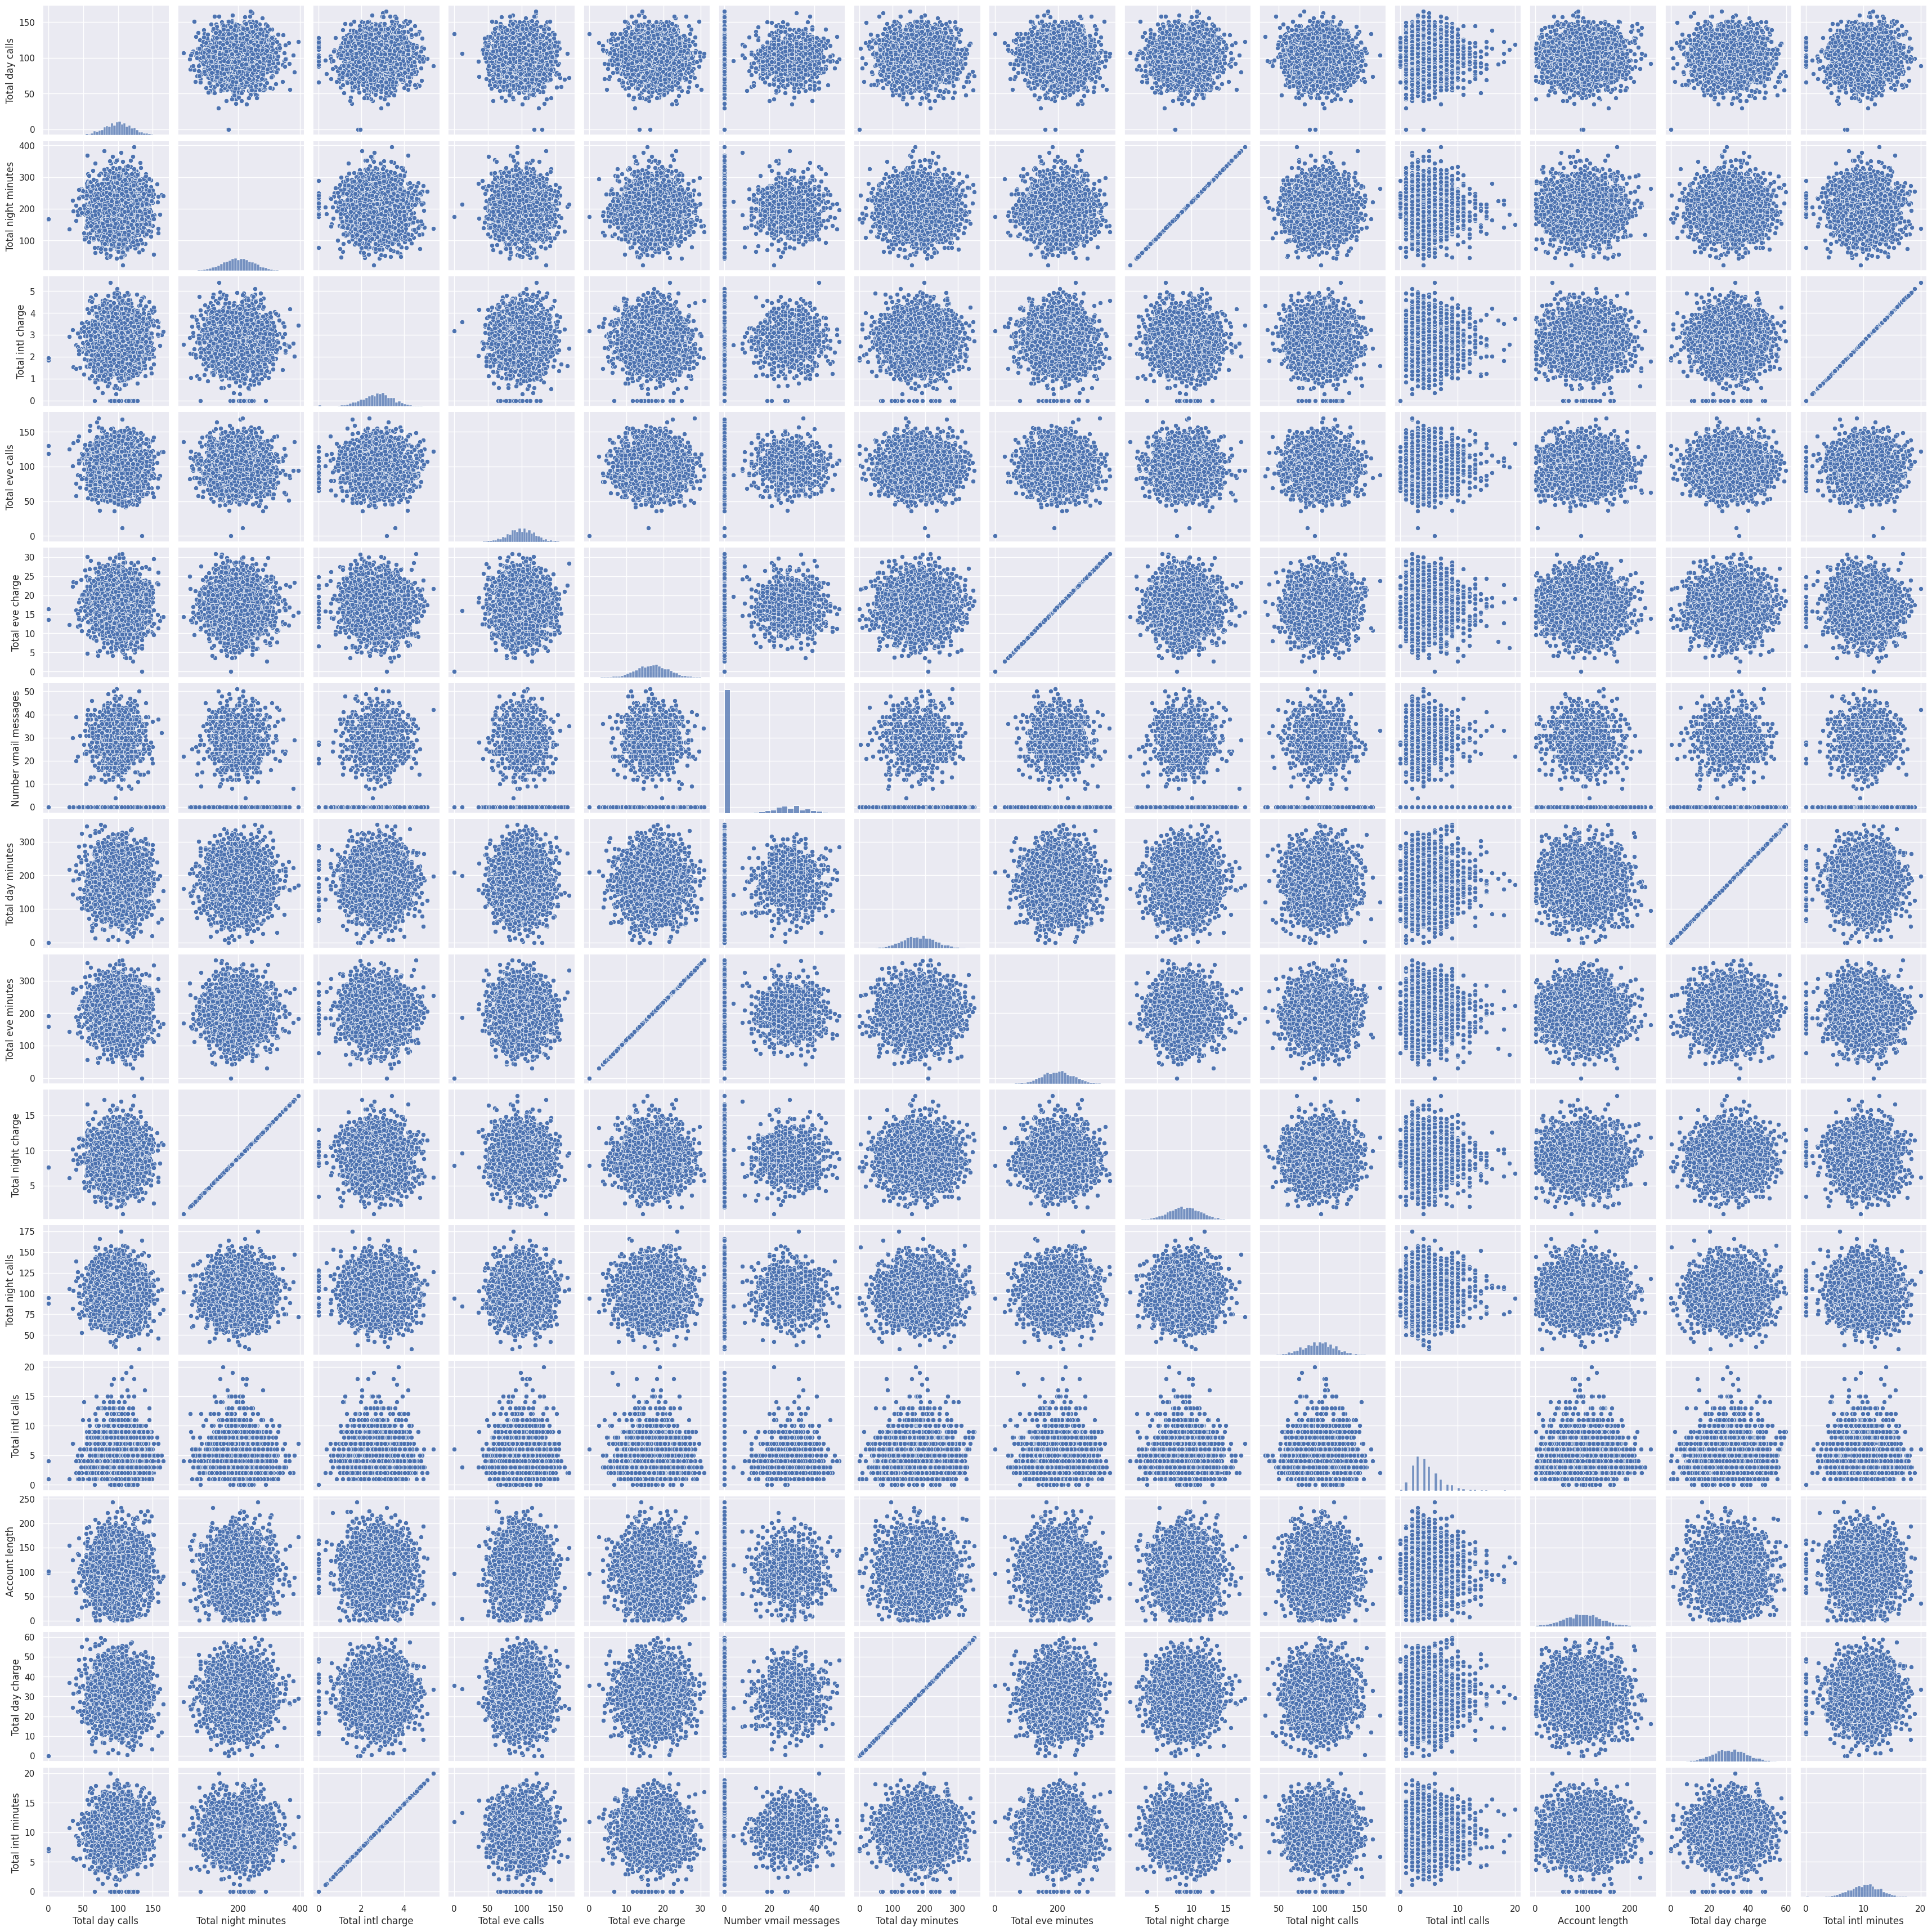

In [ ]:
# `pairplot()` may become very slow with the SVG format
%config InlineBackend.figure_format = 'png'
sns.pairplot(df[numerical]);

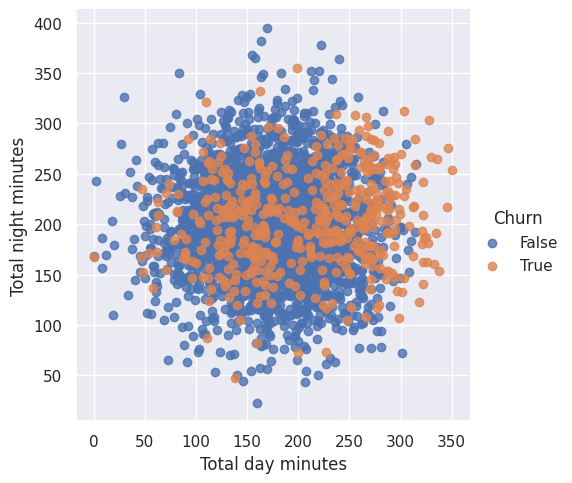

In [ ]:
sns.lmplot(
x="Total day minutes", y="Total night minutes", data=df, hue="Churn", fit_reg=False
);

IndexError: index 3 is out of bounds for axis 0 with size 3

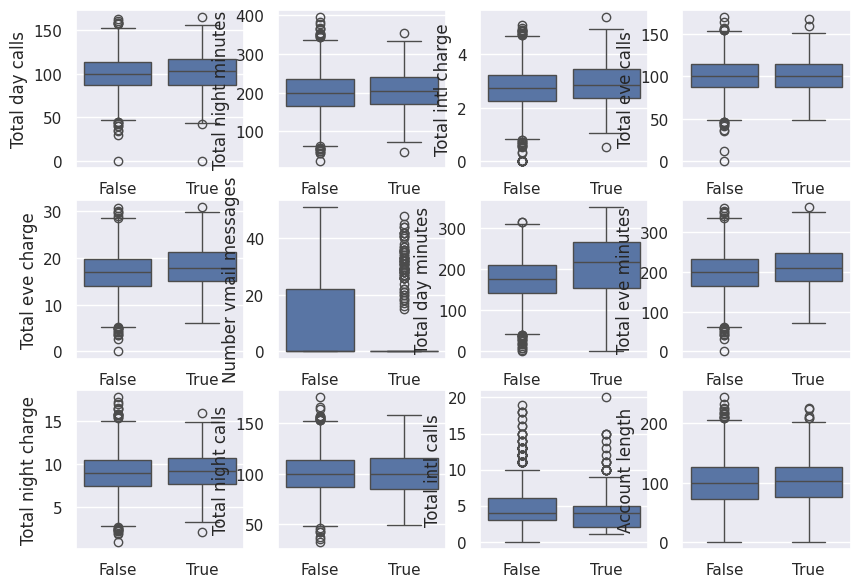

In [ ]:
# Sometimes you can analyze an ordinal variable just as numerical one
numerical.append("Customer service calls")
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 7))
for idx, feat in enumerate(numerical):
    ax = axes[int(idx / 4), idx % 4]
    sns.boxplot(x="Churn", y=feat, data=df, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(feat)
fig.tight_layout();


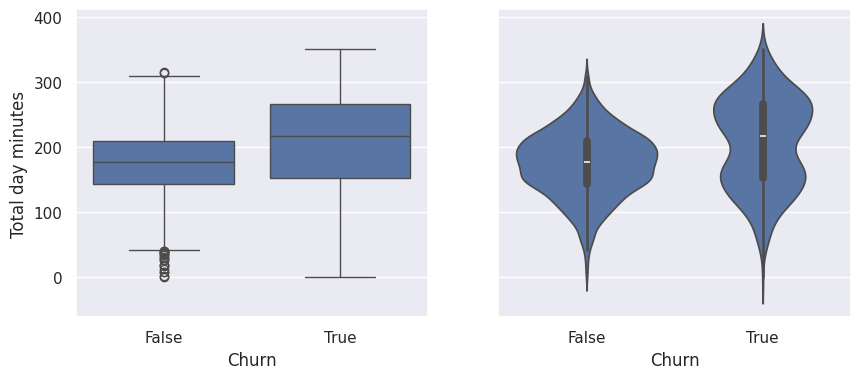

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
sns.boxplot(x="Churn", y="Total day minutes", data=df, ax=axes[0])
sns.violinplot(x="Churn", y="Total day minutes", data=df, ax=axes[1]);

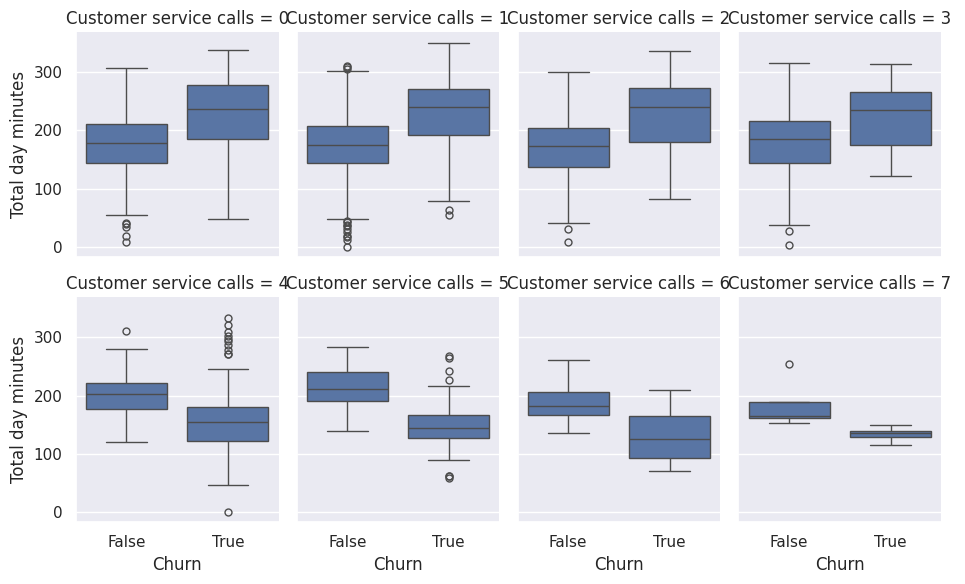

In [ ]:
sns.catplot(
x="Churn",
y="Total day minutes",
col="Customer service calls",
data=df[df["Customer service calls"] < 8],
kind="box",
col_wrap=4,
height=3,
aspect=0.8,
);

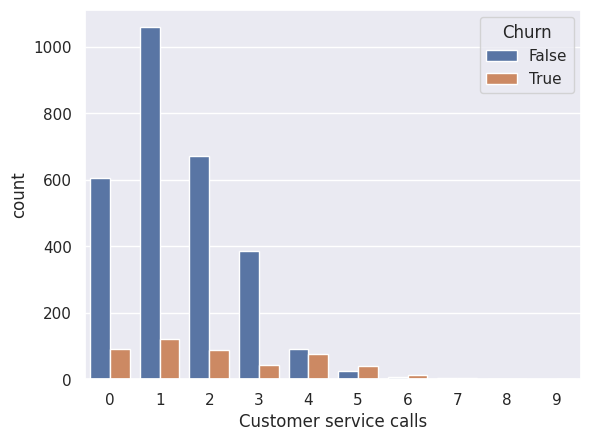

In [ ]:
sns.countplot(x="Customer service calls", hue="Churn", data=df);

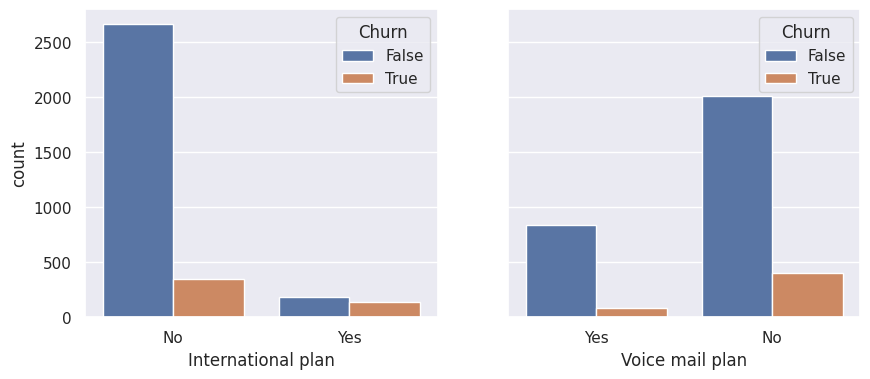

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
sns.countplot(x="International plan", hue="Churn", data=df, ax=axes[0])
sns.countplot(x="Voice mail plan", hue="Churn", data=df, ax=axes[1]);

In [ ]:
pd.crosstab(df["State"], df["Churn"]).T

State,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Churn,,,,,,,,,,,,,,,,,,,,,
False,49,72,44,60,25,57,62,49,52,55,...,52,48,54,62,72,65,52,71,96,68
True,3,8,11,4,9,9,12,5,9,8,...,8,5,18,10,5,8,14,7,10,9
